In [38]:
"""
GradCAM Explainability Pipeline for True 3D CNN Models.

Generates structured multi-patient panel grids extracting center orthogonal 
slices from 3D volumes alongside an interactive 3D HTML visualization.
"""

import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from itertools import product, combinations

sys.path.insert(0, os.path.abspath('/home/akarel/src_tfg/'))
from src.architectures import ParkinsonClassifier3D, ParkinsonClassifier3D_deeper, ParkinsonClassifierMed3D, ParkinsonClassifierMed3DEncoder
from src.transforms import get_3d_padding_cropping_transforms # Updated for 3D
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [39]:
import matplotlib.font_manager as fm
import matplotlib
fm._load_fontmanager(try_read_cache=False)
fm.fontManager.addfont("/home/akarel/.local/share/fonts/LinLibertine_R.ttf")
matplotlib.rcParams["font.family"] = "Linux Libertine"
matplotlib.rcParams["font.size"] = 11

In [40]:
CONFIG = {
    "weights_path": "/home/akarel/src_tfg/outputs/med3d_encoder_raw_5fold_20260518_042459/fold_2/best_model.pth",
    "data_csv":     "/home/akarel/src_tfg/data/ppmi_rawdata_sesBL_mapping.csv",
    "roi_size":     (76, 76, 76),
    "dropout":      0.3,
    "batch_size":   1,
    "seed":         42,
    "max_display_patients": 3,
    "output_dir":   "/home/akarel/src_tfg/analysis/outputs/gradcam/pretty_3d",
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")


# Model Initialization
model = ParkinsonClassifierMed3DEncoder(dropout_rate=CONFIG["dropout"])
model.load_state_dict(torch.load(CONFIG["weights_path"], map_location=device))
model.to(device).eval()

# Point directly to the final Conv3D layer inside features sequential
target_layers = [model.layer4]

# Placeholder for your 3D data pipeline transformation
transform = get_3d_padding_cropping_transforms(CONFIG["roi_size"])


# Dataset Stratification Block
df = pd.read_csv(CONFIG["data_csv"])
balanced = pd.concat([df[df["label"] == 1].sample(n=len(df[df["label"] == 0]), random_state=CONFIG["seed"]), df[df["label"] == 0]]).reset_index(drop=True)
_, test_df = train_test_split(balanced, test_size=0.2, stratify=balanced["label"], random_state=CONFIG["seed"])
pd_test = test_df[test_df["label"] == 1].reset_index(drop=True)
hc_test = test_df[test_df["label"] == 0].reset_index(drop=True)


/home/akarel/src_tfg/src/resnet.py:175: FutureWarning: `nn.init.kaiming_normal` is now deprecated in favor of `nn.init.kaiming_normal_`.
  m.weight = nn.init.kaiming_normal(m.weight, mode='fan_out')


  [WARN] No weights at mednetWeights/pretrain/resnet_10.pth, training from scratch


/home/akarel/src_tfg/pt_env/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [41]:
def load_image_tensor(row):
    item = transform({"image": row["path"], "label": row["label"]})
    return item["image"].unsqueeze(0) # Returns shape (1, 1, H, W, D)

def run_gradcam_inference(group_df, max_patients):
    cam = GradCAM(model=model, target_layers=target_layers)
    cams, imgs_raw, predictions = [], [], []

    for i in range(min(max_patients, len(group_df))):
        row = group_df.iloc[i]
        tensor = load_image_tensor(row).to(device)

        # pytorch-grad-cam natively outputs (H, W, D) for 3D inputs
        grayscale_cam = cam(input_tensor=tensor, targets=None)[0]

        with torch.no_grad():
            logit = model(tensor).item()
            prob = 1 / (1 + np.exp(-logit))

        cams.append(grayscale_cam)
        # Squeezing outputs to cleanly isolate spatial configurations: (H, W, D)
        imgs_raw.append(tensor.squeeze(0).squeeze(0).cpu().numpy())
        predictions.append(prob)
        
    return cams, imgs_raw, predictions

def plot_gradcam(cams, imgs_tensor, preds, arch_name, filename_base):
    n_patients = len(cams)
    PLANE_NAMES = ["Axial View", "Coronal View", "Sagittal View"]
    
    fig, axes = plt.subplots(3, n_patients * 2, figsize=(n_patients * 5.5, 8.5))
    
    for i in range(n_patients):
        img_3d = imgs_tensor[i]
        cam_3d = cams[i]
        
        col_raw = i * 2
        col_cam = i * 2 + 1
        
        # Compute geometric centers for slicing a 3D matrix
        h, w, d = img_3d.shape
        cx, cy, cz = h // 2, w // 2, d // 2
        
        # Extract corresponding 2D slices along standard radiology orientations
        slices_raw = [img_3d[:, :, cz], img_3d[:, cy, :], img_3d[cx, :, :]]
        slices_cam = [cam_3d[:, :, cz], cam_3d[:, cy, :], cam_3d[cx, :, :]]
        
        for plane_idx in range(3):
            ax_raw = axes[plane_idx, col_raw]
            ax_cam = axes[plane_idx, col_cam]
            
            raw_slice = slices_raw[plane_idx]
            cam_slice = slices_cam[plane_idx]
            
            # Normalize slice scale values
            raw_norm = (raw_slice - raw_slice.min()) / (raw_slice.max() - raw_slice.min() + 1e-8)
            raw_rgb = np.stack([raw_norm] * 3, axis=-1).astype(np.float32)
            
            overlay = show_cam_on_image(raw_rgb, cam_slice, use_rgb=True)
            
            ax_raw.imshow(raw_norm, cmap="gray")
            ax_raw.axis("off")
            
            ax_cam.imshow(overlay)
            ax_cam.axis("off")
            
            if i == 0:
                ax_raw.text(-12, raw_norm.shape[0]//2, PLANE_NAMES[plane_idx], rotation=90, 
                            ha="center", va="center", fontsize=11)
            
            if plane_idx == 0:
                ax_raw.set_title("Raw Input", fontsize=9, style="italic", pad=4)
                ax_cam.set_title("CAM Overlay", fontsize=9, style="italic", pad=4)

        axes[0, col_raw].text(h, -12, f"Patient Sample #{i+1}\nP (PD) = {preds[i]:.3f} ({arch_name})", 
                              ha="center", va="bottom", fontsize=11)


    plt.subplots_adjust(wspace=0.15, hspace=0.15)
    out_svg = os.path.join(CONFIG["output_dir"], f"{filename_base}-{arch_name}.svg")
    fig.savefig(out_svg, bbox_inches="tight", dpi=200)
    plt.close()
    print(f"Graphic successfully saved to: {out_svg}")

def plot_mean_3d_scatter_cam(cams, filename, title, threshold_percentile=95.0):
    """
    Computes the global average volume from a list of 3D Grad-CAM maps
    and renders the high-intensity mean activations as a 3D scatter point cloud.
    """

    # Stack along a new axis and compute the mean across all patient volumes
    mean_cam_3d = np.stack(cams).mean(axis=0)
    
    fig = plt.figure(figsize=(6, 5.5))
    ax = fig.add_subplot(1, 1, 1, projection='3d')
    
    dx, dy, dz = mean_cam_3d.shape
    
    # Draw gray wireframe bounding box around the volume dimensions
    r = [[0, dx], [0, dy], [0, dz]]
    for s, e in combinations(np.array(list(product(*r))), 2):
        if np.sum(np.abs(s - e)) in [dx, dy, dz]:
            ax.plot3D(*zip(s, e), color="darkgray", linewidth=1.2, linestyle="--")
            
    # Isolate high-intensity voxels on the averaged map
    thresh = np.percentile(mean_cam_3d, threshold_percentile)
    x_idx, y_idx, z_idx = np.where(mean_cam_3d > thresh)
    intensities = mean_cam_3d[mean_cam_3d > thresh]
    
    # Plot 3D point cloud
    sc = ax.scatter(x_idx, y_idx, z_idx, c=intensities, cmap='turbo', s=1, alpha=0.2)
    
    ax.set_title(title, pad=15)
    ax.set_xlim(0, dx)
    ax.set_ylim(0, dy)
    ax.set_zlim(0, dz)
    ax.axis('off')  
    
    # Colorbar tracking the averaged activation scale weights
    cbar = fig.colorbar(sc, ax=ax, shrink=0.5, aspect=12, pad=0.05)
    cbar.set_label('Mean CAM Intensity', rotation=270, labelpad=15, fontsize=9)
    
    out_img = os.path.join(CONFIG["output_dir"], filename)
    fig.savefig(out_img, bbox_inches="tight", dpi=200)
    plt.show()
    plt.close()
    print(f"Mean 3D scatter plot successfully saved to: {out_img}")


In [42]:
print(f"\nEvaluating 3D visual attention vectors via GradCAM on {device}...")

pd_cams, pd_imgs, pd_preds = run_gradcam_inference(pd_test, CONFIG["max_display_patients"])
hc_cams, hc_imgs, hc_preds = run_gradcam_inference(hc_test, CONFIG["max_display_patients"])



Evaluating 3D visual attention vectors via GradCAM on cuda:1...


In [43]:
# Standard Multi-patient panel configuration (Static 2D center slices)
plot_gradcam(pd_cams, pd_imgs, pd_preds, "med3d_encoder", "gradcam_PD_panel")
plot_gradcam(hc_cams, hc_imgs, hc_preds, "med3d_encoder", "gradcam_HC_panel")

Graphic successfully saved to: /home/akarel/src_tfg/analysis/outputs/gradcam/pretty_3d/gradcam_PD_panel-med3d_encoder.svg
Graphic successfully saved to: /home/akarel/src_tfg/analysis/outputs/gradcam/pretty_3d/gradcam_HC_panel-med3d_encoder.svg


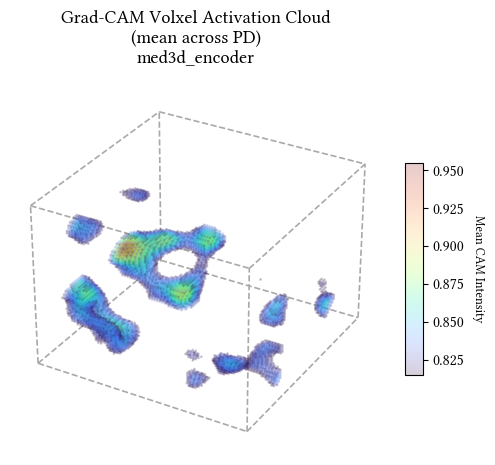

Mean 3D scatter plot successfully saved to: /home/akarel/src_tfg/analysis/outputs/gradcam/pretty_3d/gradcam_med3d_encoder_PD_scatter_mean.svg


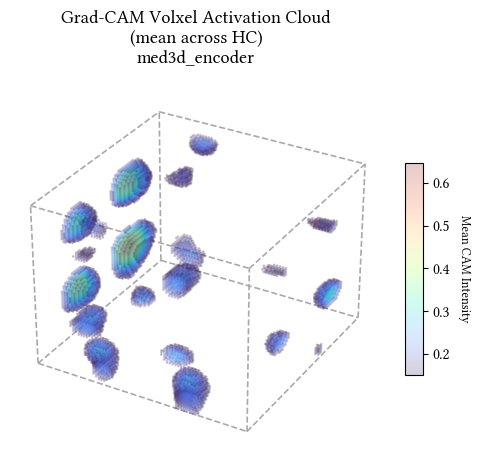

Mean 3D scatter plot successfully saved to: /home/akarel/src_tfg/analysis/outputs/gradcam/pretty_3d/gradcam_med3d_encoder_HC_scatter_mean.svg


In [44]:
plot_mean_3d_scatter_cam(
    cams=pd_cams,
    title="Grad-CAM Volxel Activation Cloud\n(mean across PD)\nmed3d_encoder",
    filename="gradcam_med3d_encoder_PD_scatter_mean.svg", 
    threshold_percentile=97.0
)
plot_mean_3d_scatter_cam(
    cams=hc_cams,
    title="Grad-CAM Volxel Activation Cloud\n(mean across HC)\nmed3d_encoder",
    filename="gradcam_med3d_encoder_HC_scatter_mean.svg", 
    threshold_percentile=97.0
)

# Sanity check


shape image_cropped: (76, 76, 76)
shape gradcam_map: (76, 76, 76)


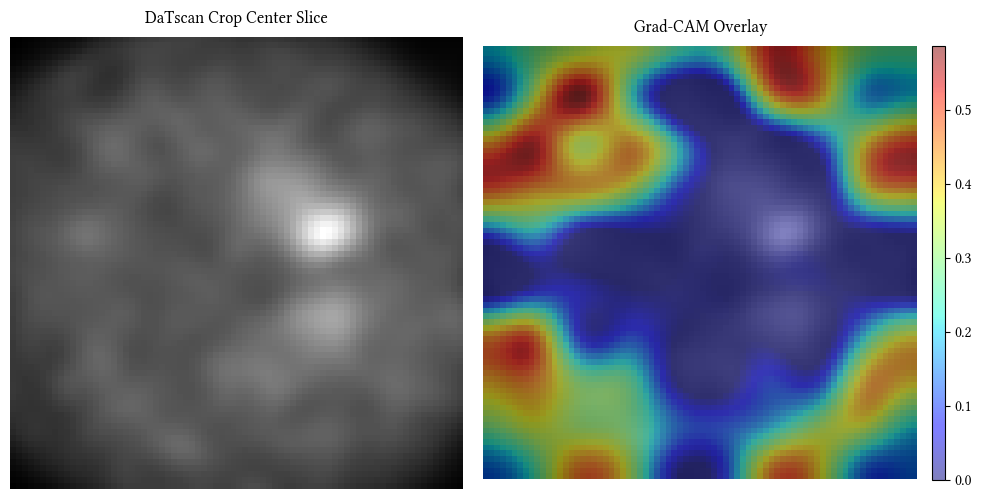

shape image_cropped: (76, 76, 76)
shape gradcam_map: (76, 76, 76)


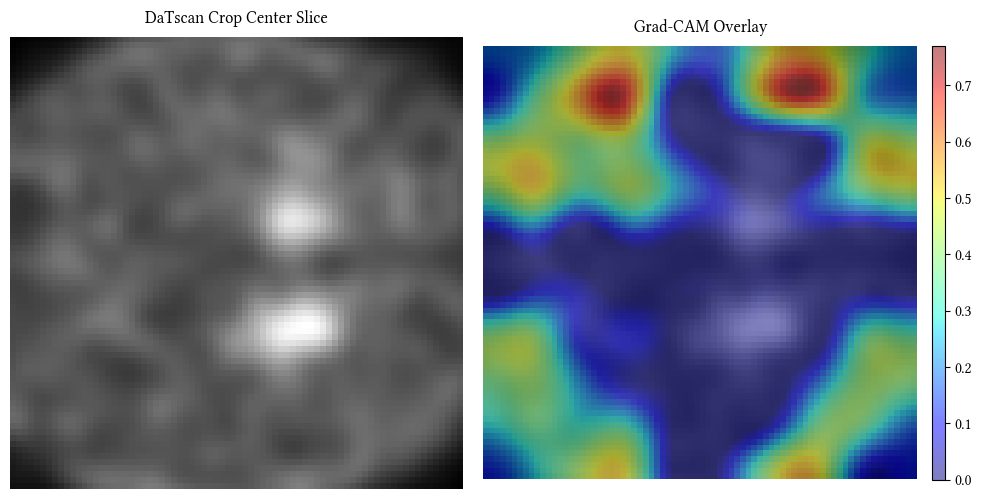

shape image_cropped: (76, 76, 76)
shape gradcam_map: (76, 76, 76)


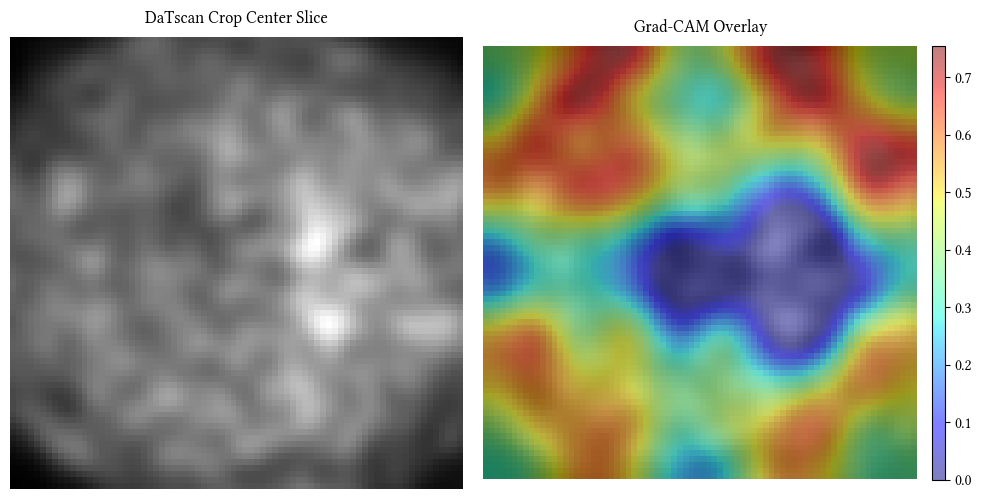

In [50]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

for idx in range(3):
    image_cropped = pd_imgs[idx]
    gradcam_map = pd_cams[idx]
    slice_idx = 38  # Middle of the volume

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    print(f"shape image_cropped: {image_cropped.shape}")
    print(f"shape gradcam_map: {gradcam_map.shape}")

    axes[0].imshow(image_cropped[:, :, slice_idx], cmap="gray")
    axes[0].set_title("DaTscan Crop Center Slice", fontsize=12, pad=10)
    axes[0].axis("off")


    axes[1].imshow(image_cropped[:, :, slice_idx], cmap="gray")
    # Save the plot object to 'im' so the colorbar knows the scale
    axes[1].set_title("Grad-CAM Overlay", fontsize=12, pad=10)
    axes[1].axis("off")
    im = axes[1].imshow(gradcam_map[:, :, slice_idx], cmap="jet", alpha=0.5)
    

    # Append an axis to the right of axes[1] that matches its exact height
    divider = make_axes_locatable(axes[1])
    cax = divider.append_axes("right", size="3%", pad=0.15)
    fig.colorbar(im, cax=cax)
    plt.subplots_adjust(wspace=0.15, hspace=0.15)    
    plt.tight_layout()   
    plt.show()